# Monopoly Property Landing Probability
Starter notebook for estimating long-run landing probability on each board square.

In [6]:
using Pkg
Pkg.activate("..")

  Activating project at `c:\Users\RemiLequette\Development\julia\Monopoly`


In [17]:
include("../src/MonopolyProbability.jl")
include("../src/MonopolyVisualization.jl")

board = MonopolyProbability.standard_board()

# Graphical board rendering with Plots.jl
function show(probabilities)
    p = MonopolyVisualization.plot_board_heatmap(probabilities; labels=board, label_chars=12)
    display(p)
end

show (generic function with 1 method)

In [10]:
function test_simulation()
    probabilities = MonopolyProbability.initial_probability_distribution()
    probabilities = MonopolyProbability.simulate_n_throws(probabilities, 5000)
    show(probabilities)
end
#test_simulation()

test_simulation (generic function with 1 method)

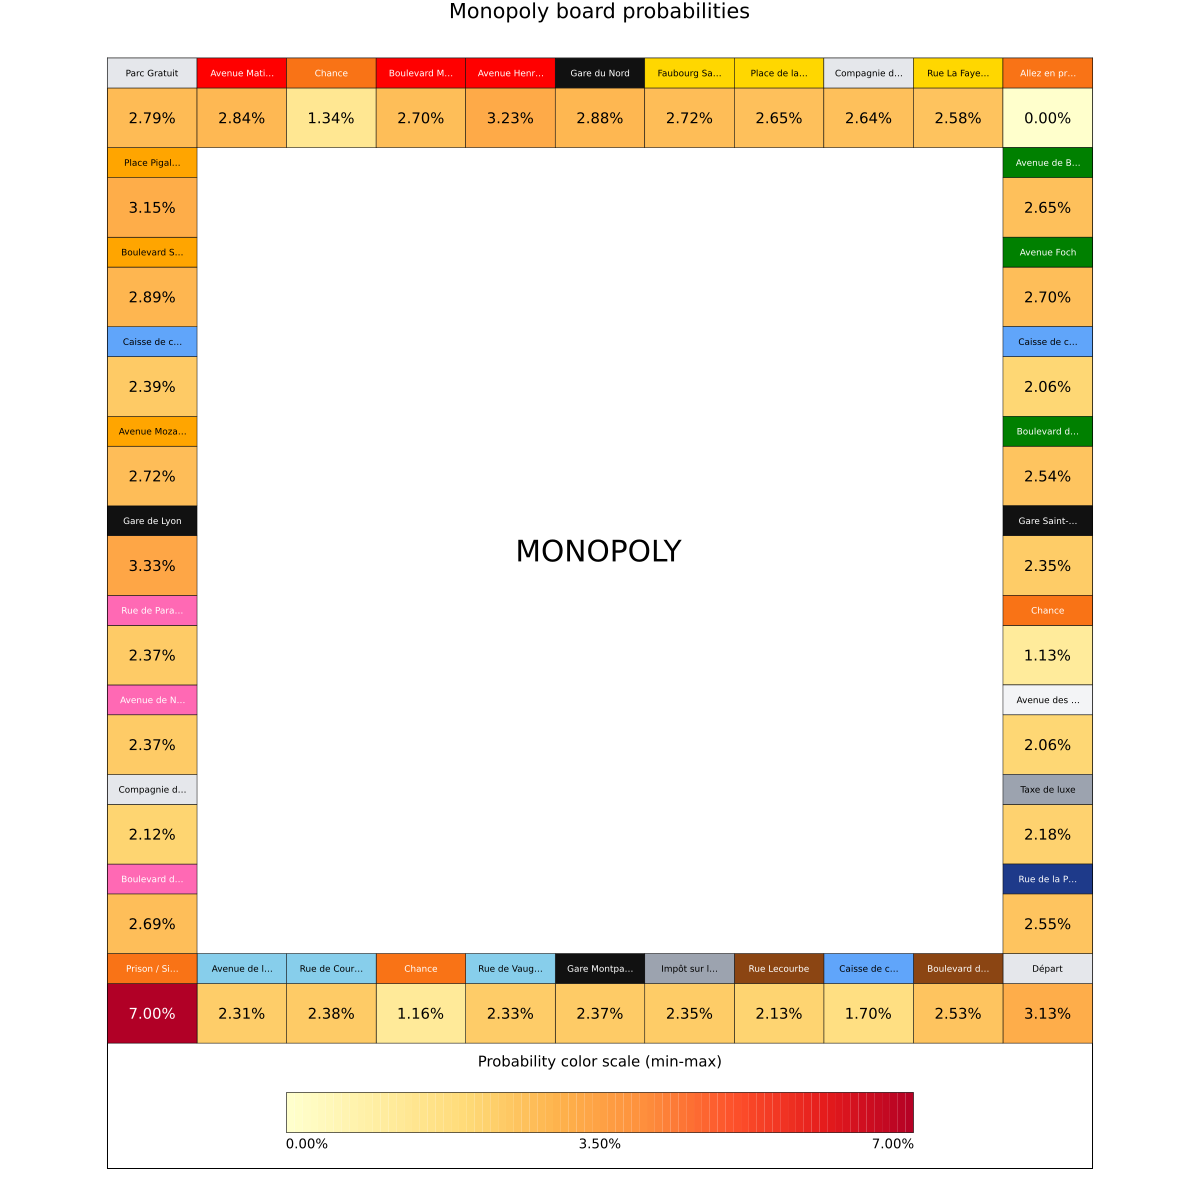

Converged: true after 94 iterations
11 - Prison / Simple visite         : 7.001%
16 - Gare de Lyon                   : 3.3301%
25 - Avenue Henri-Martin            : 3.2295%
20 - Place Pigalle                  : 3.1485%
 1 - Départ                         : 3.1286%
19 - Boulevard Saint-Michel         : 2.8915%
26 - Gare du Nord                   : 2.8753%
22 - Avenue Matignon                : 2.8399%
21 - Parc Gratuit                   : 2.7854%
27 - Faubourg Saint-Honoré          : 2.7236%

Top-10 expected landings per turn (rentability proxy):
11 - Prison / Simple visite         : 7.4517%
16 - Gare de Lyon                   : 3.8826%
25 - Avenue Henri-Martin            : 3.8066%
 1 - Départ                         : 3.6736%
20 - Place Pigalle                  : 3.644%
19 - Boulevard Saint-Michel         : 3.4907%
26 - Gare du Nord                   : 3.4523%
21 - Parc Gratuit                   : 3.4048%
22 - Avenue Matignon                : 3.3574%
17 - Avenue Mozart                  

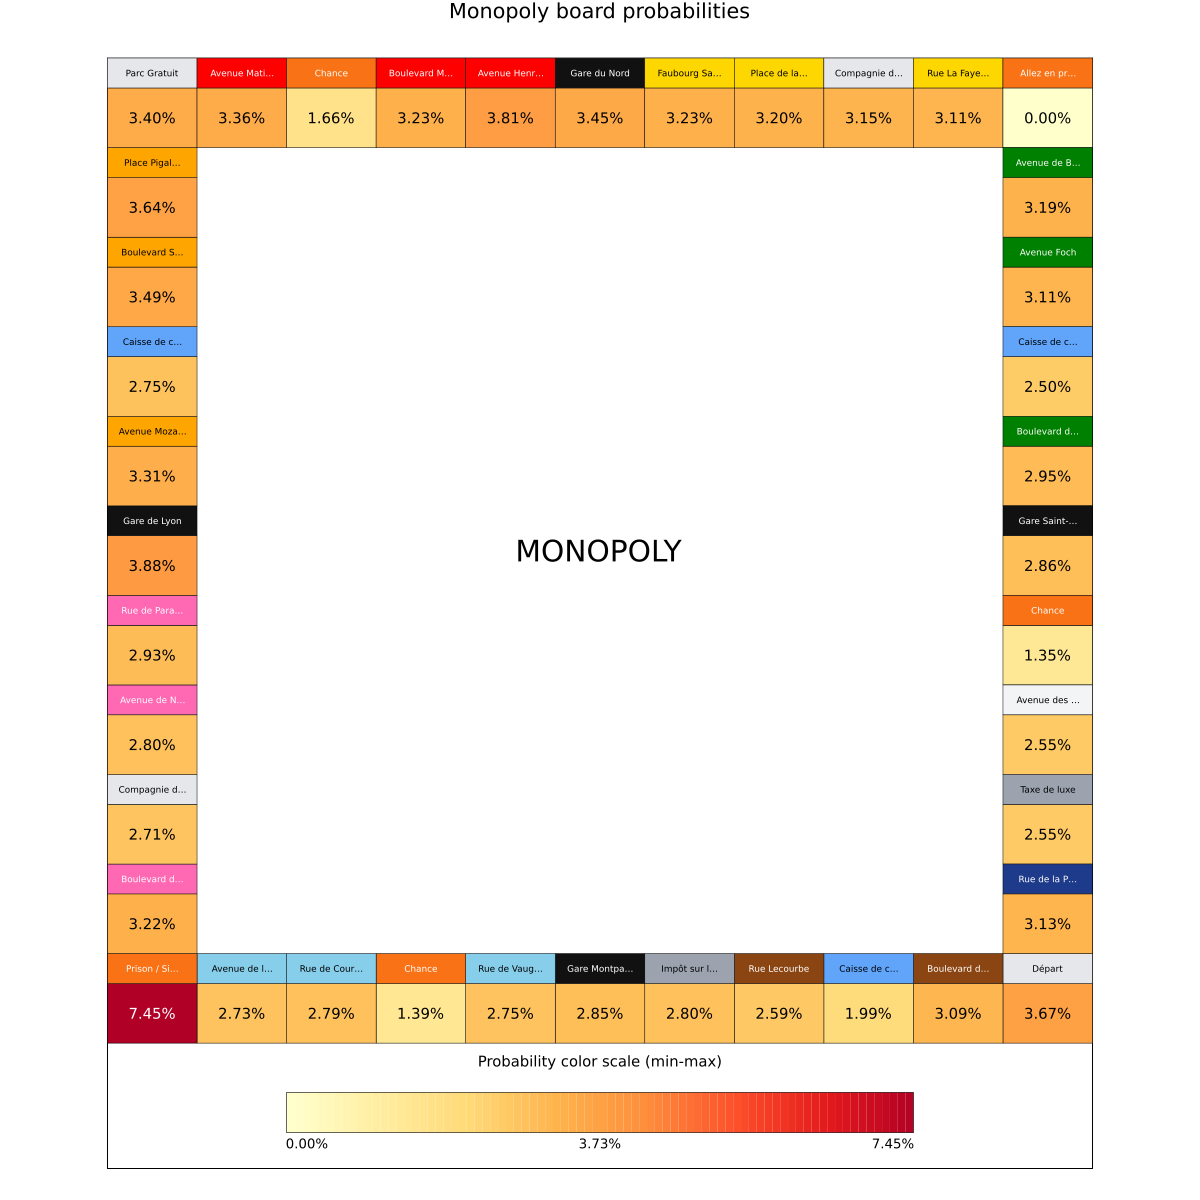

In [18]:
# Long-run convergent probabilities (stationary distribution) with doubles rule
transition = MonopolyProbability.dice_transition_matrix(include_doubles=true)
stationary_probabilities, iterations, converged = MonopolyProbability.convergent_probabilities(transition)
println("Converged: ", converged, " after ", iterations, " iterations")

# Optional: reuse plotting helper from previous cells
show(stationary_probabilities)

# Top-10 most visited squares at turn boundaries
top_idx = sortperm(stationary_probabilities, rev=true)[1:10]
for idx in top_idx
    println(lpad(idx, 2), " - ", rpad(board[idx], 30), " : ", round(100 * stationary_probabilities[idx], digits=4), "%")
end

# Expected payable landings during one full turn (includes extra rolls from doubles)
landings_per_turn = MonopolyProbability.expected_landings_per_turn(stationary_probabilities; include_doubles=true)
rentability_idx = sortperm(landings_per_turn, rev=true)[1:10]
println("\nTop-10 expected landings per turn (rentability proxy):")
for idx in rentability_idx
    println(lpad(idx, 2), " - ", rpad(board[idx], 30), " : ", round(100 * landings_per_turn[idx], digits=4), "%")
end
show(landings_per_turn)

In [19]:
# Jail policy sensitivity analysis: pay immediately vs try doubles then pay
transition_pay = MonopolyProbability.dice_transition_matrix(include_doubles=true, jail_policy=:pay_immediately)
transition_try_80 = MonopolyProbability.dice_transition_matrix_with_jail_state(include_doubles=true, jail_policy=:try_doubles_then_pay)

pi_pay, _, _ = MonopolyProbability.convergent_probabilities(transition_pay)
pi_try_80, _, _ = MonopolyProbability.convergent_probabilities(transition_try_80)
pi_try = MonopolyProbability.collapse_turn_state_distribution(pi_try_80)

landings_pay = MonopolyProbability.expected_landings_per_turn(pi_pay; include_doubles=true, jail_policy=:pay_immediately)
landings_try = MonopolyProbability.expected_landings_per_turn(pi_try_80; include_doubles=true, jail_policy=:try_doubles_then_pay)

delta_stationary = pi_try .- pi_pay
delta_landings = landings_try .- landings_pay

println("Top-10 absolute deltas (TRY_DOUBLES_THEN_PAY - PAY_IMMEDIATELY)")
println("\nTurn-boundary stationary probabilities:")
idx_stationary = sortperm(abs.(delta_stationary), rev=true)[1:10]
for idx in idx_stationary
    println(
        lpad(idx, 2),
        " - ",
        rpad(board[idx], 30),
        " | pay=", round(100 * pi_pay[idx], digits=4),
        "% | try=", round(100 * pi_try[idx], digits=4),
        "% | Δ=", round(100 * delta_stationary[idx], digits=4), "%"
    )
end

println("\nExpected landings per turn:")
idx_landings = sortperm(abs.(delta_landings), rev=true)[1:10]
for idx in idx_landings
    println(
        lpad(idx, 2),
        " - ",
        rpad(board[idx], 30),
        " | pay=", round(100 * landings_pay[idx], digits=4),
        "% | try=", round(100 * landings_try[idx], digits=4),
        "% | Δ=", round(100 * delta_landings[idx], digits=4), "%"
    )
end

Top-10 absolute deltas (TRY_DOUBLES_THEN_PAY - PAY_IMMEDIATELY)

Turn-boundary stationary probabilities:
11 - Prison / Simple visite         | pay=7.001% | try=24.6912% | Δ=17.6902%
16 - Gare de Lyon                   | pay=3.3301% | try=2.3085% | Δ=-1.0216%
20 - Place Pigalle                  | pay=3.1485% | try=2.2267% | Δ=-0.9218%
18 - Caisse de communauté           | pay=2.3928% | try=1.4732% | Δ=-0.9196%
22 - Avenue Matignon                | pay=2.8399% | try=2.1153% | Δ=-0.7245%
25 - Avenue Henri-Martin            | pay=3.2295% | try=2.5194% | Δ=-0.7101%
14 - Avenue de Neuilly              | pay=2.3709% | try=1.6881% | Δ=-0.6828%
 1 - Départ                         | pay=3.1286% | try=2.5073% | Δ=-0.6213%
27 - Faubourg Saint-Honoré          | pay=2.7236% | try=2.114% | Δ=-0.6096%
29 - Compagnie des eaux             | pay=2.6366% | try=2.0899% | Δ=-0.5467%

Expected landings per turn:
11 - Prison / Simple visite         | pay=7.4517% | try=25.0523% | Δ=17.6006%
16 - Gare de Lyon  